<a href="https://colab.research.google.com/github/asheta66/Data-Mining/blob/main/GAs/Genetic_Algorithm_for_Feature_Selection_ver1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genetic Algorithm for Feature Selection — Corrected and Reproducible

This notebook fixes the original implementation and adds:

- datasets that are always available for simulation (no Kaggle credentials required),
- validation-based GA fitness to avoid test-set leakage,
- train and test evaluation tables with accuracy, precision, recall, and F1,
- GA tuning parameters and tuning results in DataFrame tables,
- best-so-far convergence curves for every dataset,
- reproducible random seeds and selected-feature summaries.

The Breast Cancer dataset is loaded from scikit-learn. Parkinson-like and PCOS-like datasets are generated with `make_classification` so the notebook runs offline. Replace those simulated datasets with real CSV files later without changing the GA workflow.

In [1]:
import copy
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)

## 1. Reproducible dataset loaders

The loader first checks for optional local real-data CSV files. When they are not present, it creates deterministic simulated data, ensuring that all experiments remain runnable.

In [2]:
def _clean_numeric_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Convert columns to numeric, replace infinities, and median-impute missing values."""
    out = df.copy()
    for col in out.columns:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)
    return out.fillna(out.median(numeric_only=True)).fillna(0)


def load_datasets(data_dir: str = "data"):
    data_dir = Path(data_dir)
    datasets = {}

    # Always available offline from scikit-learn.
    bc = load_breast_cancer(as_frame=True)
    datasets["Breast Cancer"] = (bc.data, bc.target.astype(int), "sklearn built-in")

    # Optional real Parkinson CSV; otherwise deterministic simulation.
    parkinson_candidates = [
        data_dir / "Parkinsson disease.csv",
        data_dir / "parkinsons.csv",
        Path("Parkinsson disease.csv"),
        Path("parkinsons.csv"),
    ]
    parkinson_file = next((p for p in parkinson_candidates if p.exists()), None)
    if parkinson_file:
        raw = pd.read_csv(parkinson_file)
        y = raw.pop("status").astype(int)
        raw = raw.drop(columns=["name"], errors="ignore")
        X = _clean_numeric_frame(raw)
        source = str(parkinson_file)
    else:
        X_arr, y_arr = make_classification(
            n_samples=320, n_features=22, n_informative=10, n_redundant=5,
            weights=[0.35, 0.65], class_sep=1.15, flip_y=0.03,
            random_state=RANDOM_STATE + 1,
        )
        X = pd.DataFrame(X_arr, columns=[f"voice_feature_{i+1}" for i in range(22)])
        y = pd.Series(y_arr, name="status")
        source = "simulated offline dataset"
    datasets["Parkinson"] = (X, y, source)

    # Optional real PCOS CSV; otherwise deterministic simulation.
    pcos_candidates = [data_dir / "PCOS_data.csv", Path("PCOS_data.csv")]
    pcos_file = next((p for p in pcos_candidates if p.exists()), None)
    if pcos_file:
        raw = pd.read_csv(pcos_file)
        target = "PCOS (Y/N)"
        y = pd.to_numeric(raw.pop(target), errors="coerce").fillna(0).astype(int)
        raw = raw.drop(columns=["Sl. No", "Patient File No.", "Unnamed: 44"], errors="ignore")
        X = _clean_numeric_frame(raw)
        source = str(pcos_file)
    else:
        X_arr, y_arr = make_classification(
            n_samples=360, n_features=41, n_informative=14, n_redundant=8,
            weights=[0.68, 0.32], class_sep=1.0, flip_y=0.04,
            random_state=RANDOM_STATE + 2,
        )
        X = pd.DataFrame(X_arr, columns=[f"clinical_feature_{i+1}" for i in range(41)])
        y = pd.Series(y_arr, name="PCOS (Y/N)")
        source = "simulated offline dataset"
    datasets["PCOS"] = (X, y, source)

    return datasets


datasets = load_datasets()
dataset_summary = pd.DataFrame([
    {"Dataset": name, "Rows": len(X), "Features": X.shape[1],
     "Positive rate": float(np.mean(y)), "Source": source}
    for name, (X, y, source) in datasets.items()
])
dataset_summary

,Dataset,Rows,Features,Positive rate,Source
0,Breast Cancer,569,30,0.627417,sklearn built-in
1,Parkinson,320,22,0.631250,simulated offline dataset
2,PCOS,360,41,0.327778,simulated offline dataset


## 2. Corrected Genetic Algorithm

Important corrections include independent chromosome copies, guaranteed non-empty feature subsets, tournament selection, elitism, and cross-validated training-only fitness. The test set is untouched until final evaluation.

In [3]:
@dataclass(frozen=True)
class GAConfig:
    population_size: int = 12
    generations: int = 5
    crossover_rate: float = 0.8
    mutation_rate: float = 0.05
    elite_size: int = 2
    tournament_size: int = 3
    cv_folds: int = 2
    random_state: int = RANDOM_STATE


def initialize_population(rng, population_size, n_features):
    population = rng.random((population_size, n_features)) < 0.5
    empty = np.where(population.sum(axis=1) == 0)[0]
    for row in empty:
        population[row, rng.integers(0, n_features)] = True
    return population


def chromosome_fitness(chromosome, X_train, y_train, estimator, cv):
    selected = np.flatnonzero(chromosome)
    if len(selected) == 0:
        return 0.0
    scores = cross_val_score(
        clone(estimator), X_train.iloc[:, selected], y_train,
        cv=cv, scoring="f1", n_jobs=1
    )
    return float(scores.mean())


def tournament_select(rng, population, fitness, tournament_size):
    candidates = rng.choice(len(population), size=tournament_size, replace=False)
    return population[candidates[np.argmax(fitness[candidates])]].copy()


def crossover(rng, parent1, parent2, crossover_rate):
    if len(parent1) < 2 or rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()
    point = rng.integers(1, len(parent1))
    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])
    return child1, child2


def mutate(rng, chromosome, mutation_rate):
    child = chromosome.copy()
    child ^= (rng.random(len(child)) < mutation_rate)
    if not child.any():
        child[rng.integers(0, len(child))] = True
    return child


def run_ga(X_train, y_train, estimator, config: GAConfig):
    rng = np.random.default_rng(config.random_state)
    cv = StratifiedKFold(n_splits=config.cv_folds, shuffle=True,
                         random_state=config.random_state)
    population = initialize_population(rng, config.population_size, X_train.shape[1])
    best_chromosome = None
    best_fitness = -np.inf
    history = []

    for generation in range(1, config.generations + 1):
        fitness = np.array([
            chromosome_fitness(ch, X_train, y_train, estimator, cv)
            for ch in population
        ])
        order = np.argsort(fitness)[::-1]
        population, fitness = population[order], fitness[order]

        if fitness[0] > best_fitness:
            best_fitness = float(fitness[0])
            best_chromosome = population[0].copy()

        history.append({
            "Generation": generation,
            "Best in generation": float(fitness[0]),
            "Best so far": best_fitness,
            "Mean fitness": float(fitness.mean()),
            "Selected features (best so far)": int(best_chromosome.sum()),
        })

        next_population = [population[i].copy() for i in range(config.elite_size)]
        while len(next_population) < config.population_size:
            p1 = tournament_select(rng, population, fitness, config.tournament_size)
            p2 = tournament_select(rng, population, fitness, config.tournament_size)
            c1, c2 = crossover(rng, p1, p2, config.crossover_rate)
            next_population.append(mutate(rng, c1, config.mutation_rate))
            if len(next_population) < config.population_size:
                next_population.append(mutate(rng, c2, config.mutation_rate))
        population = np.asarray(next_population, dtype=bool)

    return best_chromosome, best_fitness, pd.DataFrame(history)

## 3. GA tuning parameter table

In [4]:
TUNING_CONFIGS = [
    GAConfig(population_size=10, generations=4, crossover_rate=0.75, mutation_rate=0.03, elite_size=2, tournament_size=3, cv_folds=2),
    GAConfig(population_size=10, generations=4, crossover_rate=0.85, mutation_rate=0.05, elite_size=2, tournament_size=3, cv_folds=2),
    GAConfig(population_size=14, generations=5, crossover_rate=0.80, mutation_rate=0.05, elite_size=2, tournament_size=3, cv_folds=2),
]

ga_parameter_df = pd.DataFrame([
    {"Configuration": f"GA-{i+1}", **asdict(cfg)}
    for i, cfg in enumerate(TUNING_CONFIGS)
])
ga_parameter_df

,Configuration,population_size,generations,crossover_rate,mutation_rate,elite_size,tournament_size,cv_folds,random_state
0,GA-1,10,4,0.75,0.03,2,3,2,42
1,GA-2,10,4,0.85,0.05,2,3,2,42
2,GA-3,14,5,0.80,0.05,2,3,2,42


## 4. Tune, train, and evaluate

For every dataset, the training portion is split internally into fit and validation subsets. GA tuning is based only on this training-side validation process. Final metrics are then reported separately for the full training set and untouched test set.

In [5]:
def metric_row(dataset, model_name, split_name, y_true, y_pred, n_selected, total_features):
    return {
        "Dataset": dataset,
        "Model": model_name,
        "Split": split_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Selected Features": n_selected,
        "Total Features": total_features,
    }


base_estimator = DecisionTreeClassifier(
    max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
)

metric_rows = []
tuning_rows = []
convergence_histories = {}
selected_feature_rows = []

for dataset_index, (dataset_name, (X, y, source)) in enumerate(datasets.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )

    best_result = None
    for config_index, cfg in enumerate(TUNING_CONFIGS, start=1):
        cfg_for_run = GAConfig(**{**asdict(cfg), "random_state": RANDOM_STATE + dataset_index})
        chromosome, cv_f1, history = run_ga(X_train, y_train, base_estimator, cfg_for_run)
        tuning_rows.append({
            "Dataset": dataset_name,
            "Configuration": f"GA-{config_index}",
            **asdict(cfg_for_run),
            "Best CV F1": cv_f1,
            "Selected Features": int(chromosome.sum()),
        })
        if best_result is None or cv_f1 > best_result[1]:
            best_result = (chromosome, cv_f1, history, cfg_for_run, config_index)

    best_chromosome, best_cv_f1, best_history, best_cfg, best_cfg_index = best_result
    convergence_histories[dataset_name] = best_history
    selected_idx = np.flatnonzero(best_chromosome)

    # Baseline: all features.
    baseline = clone(base_estimator).fit(X_train, y_train)
    metric_rows.append(metric_row(dataset_name, "Baseline (all features)", "Train",
                                  y_train, baseline.predict(X_train), X.shape[1], X.shape[1]))
    metric_rows.append(metric_row(dataset_name, "Baseline (all features)", "Test",
                                  y_test, baseline.predict(X_test), X.shape[1], X.shape[1]))

    # GA-selected model.
    ga_model = clone(base_estimator).fit(X_train.iloc[:, selected_idx], y_train)
    metric_rows.append(metric_row(dataset_name, "GA-selected features", "Train",
                                  y_train, ga_model.predict(X_train.iloc[:, selected_idx]),
                                  len(selected_idx), X.shape[1]))
    metric_rows.append(metric_row(dataset_name, "GA-selected features", "Test",
                                  y_test, ga_model.predict(X_test.iloc[:, selected_idx]),
                                  len(selected_idx), X.shape[1]))

    selected_feature_rows.append({
        "Dataset": dataset_name,
        "Best Configuration": f"GA-{best_cfg_index}",
        "Best CV F1": best_cv_f1,
        "Selected Count": len(selected_idx),
        "Selected Feature Names": ", ".join(X.columns[selected_idx]),
    })

metrics_df = pd.DataFrame(metric_rows)
tuning_results_df = pd.DataFrame(tuning_rows)
selected_features_df = pd.DataFrame(selected_feature_rows)

metrics_df

,Dataset,Model,Split,Accuracy,Precision,Recall,F1,Selected Features,Total Features
0,Breast Cancer,Baseline (all features),Train,1.000000,1.000000,1.000000,1.000000,30,30
1,Breast Cancer,Baseline (all features),Test,0.944056,0.965909,0.944444,0.955056,30,30
2,Breast Cancer,GA-selected features,Train,1.000000,1.000000,1.000000,1.000000,13,30
3,Breast Cancer,GA-selected features,Test,0.951049,0.966292,0.955556,0.960894,13,30
4,Parkinson,Baseline (all features),Train,0.975000,0.993243,0.967105,0.980000,22,22
5,Parkinson,Baseline (all features),Test,0.700000,0.760000,0.760000,0.760000,22,22
6,Parkinson,GA-selected features,Train,0.979167,0.986755,0.980263,0.983498,14,22
7,Parkinson,GA-selected features,Test,0.687500,0.727273,0.800000,0.761905,14,22
8,PCOS,Baseline (all features),Train,1.000000,1.000000,1.000000,1.000000,41,41
9,PCOS,Baseline (all features),Test,0.800000,0.700000,0.700000,0.700000,41,41


### GA tuning results

In [6]:
tuning_results_df.sort_values(["Dataset", "Best CV F1"], ascending=[True, False]).reset_index(drop=True)

,Dataset,Configuration,population_size,generations,crossover_rate,mutation_rate,elite_size,tournament_size,cv_folds,random_state,Best CV F1,Selected Features
0,Breast Cancer,GA-1,10,4,0.75,0.03,2,3,2,42,0.962724,13
1,Breast Cancer,GA-3,14,5,0.80,0.05,2,3,2,42,0.955056,11
2,Breast Cancer,GA-2,10,4,0.85,0.05,2,3,2,42,0.951099,17
3,PCOS,GA-3,14,5,0.80,0.05,2,3,2,44,0.707966,26
4,PCOS,GA-2,10,4,0.85,0.05,2,3,2,44,0.687725,19
5,PCOS,GA-1,10,4,0.75,0.03,2,3,2,44,0.651685,20
6,Parkinson,GA-1,10,4,0.75,0.03,2,3,2,43,0.819380,14
7,Parkinson,GA-3,14,5,0.80,0.05,2,3,2,43,0.803553,13
8,Parkinson,GA-2,10,4,0.85,0.05,2,3,2,43,0.798876,12


### Best selected feature subsets

In [7]:
selected_features_df

,Dataset,Best Configuration,Best CV F1,Selected Count,Selected Feature Names
0,Breast Cancer,GA-1,0.962724,13,"mean perimeter, mean smoothness, mean fractal ..."
1,Parkinson,GA-1,0.819380,14,"voice_feature_1, voice_feature_2, voice_featur..."
2,PCOS,GA-3,0.707966,26,"clinical_feature_2, clinical_feature_3, clinic..."


## 5. Best-so-far GA convergence curves

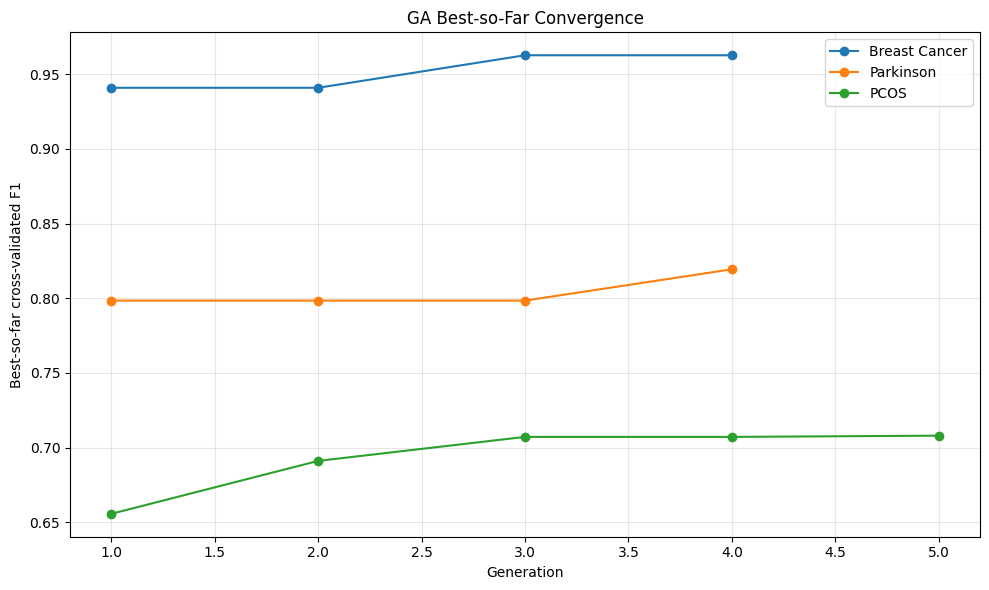

In [8]:
plt.figure(figsize=(10, 6))
for dataset_name, history in convergence_histories.items():
    plt.plot(history["Generation"], history["Best so far"], marker="o", label=dataset_name)
plt.xlabel("Generation")
plt.ylabel("Best-so-far cross-validated F1")
plt.title("GA Best-so-Far Convergence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Compact training/testing evaluation matrix

In [9]:
evaluation_matrix_df = metrics_df.pivot_table(
    index=["Dataset", "Model"],
    columns="Split",
    values=["Accuracy", "Precision", "Recall", "F1"],
).round(4)
evaluation_matrix_df

Accuracy              F1          \
Split                                     Test   Train    Test   Train   
Dataset       Model                                                      
Breast Cancer Baseline (all features)   0.9441  1.0000  0.9551  1.0000   
              GA-selected features      0.9510  1.0000  0.9609  1.0000   
PCOS          Baseline (all features)   0.8000  1.0000  0.7000  1.0000   
              GA-selected features      0.7556  1.0000  0.6452  1.0000   
Parkinson     Baseline (all features)   0.7000  0.9750  0.7600  0.9800   
              GA-selected features      0.6875  0.9792  0.7619  0.9835   

                                      Precision          Recall          
Split                                      Test   Train    Test   Train  
Dataset       Model                                                      
Breast Cancer Baseline (all features)    0.9659  1.0000  0.9444  1.0000  
              GA-selected features       0.9663  1.0000  0.9556  1.0000  
PCOS          Baseline (all features)    0.7000  1.0000  0.7000  1.0000  
              GA-selected features       0.6250  1.0000  0.6667  1.0000  
Parkinson     Baseline (all features)    0.7600  0.9932  0.7600  0.9671  
              GA-selected features       0.7273  0.9868  0.8000  0.9803

## Notes

- **No test leakage:** the GA fitness function uses stratified cross-validation on the training data only.
- **Precision/recall/F1:** binary metrics treat class `1` as positive and use `zero_division=0`.
- **Simulation access:** all three datasets run without internet access. The Parkinson and PCOS simulations are reproducible but are not substitutes for clinical conclusions.
- To use real Parkinson or PCOS data, place the expected CSV in a `data/` folder beside the notebook; the loader will use it automatically.